# Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
from helpers.data_cleaning import *
from helpers.surgery_mapping import *

# Import data

In [2]:
df = pd.read_excel("../data/ICU_research.xlsx")

# Clean Data

In [3]:
df = (
    df
    .pipe(to_snake_case)
    .pipe(drop_empty_rows)
    .pipe(drop_unnamed_index)
    .pipe(format_dates)
    .pipe(format_gender)
    .pipe(format_age)
    .pipe(format_stay_durations)
    .pipe(format_intubation)
    .pipe(format_qsofa)
    .pipe(format_categoricals)
    .pipe(add_derived_columns)
    .pipe(map_surgeries)
)

In [5]:
df.columns

Index(['year_of_birth', 'gender', 'hospital_admission_date',
       'hospital_discharge_date', 'date_of_surgery', 'type_of_surgery',
       'icu_admission_date', 'icu_discharge_date', 'intubation',
       'date_of_intubation', 'date_of_extubation', 'niv', 'type_of_admission',
       'lead_department', 'reason_for_admission_category',
       'reason_for_admission_comment', 'diagnosis_that_lead_to_admission',
       'other_diagnoses', 'other_diagnoses_free_text',
       'disability_at_discharge', 'cause_of_death', 'discharge_to', 'qsofa',
       'length_of_icu_stay_nights', 'intubation_nights',
       'hospital_stay_nights', 'discharge_after_icu_nights', 'age_years',
       'comment', 'icu_stay_check', 'hosp_stay_check',
       'type_of_surgery_grouped'],
      dtype='object')

In [6]:
df.type_of_surgery_grouped.unique()

array(['Hemi/Total Thyroidectomy', 'Other', 'EGD', 'Chest Tube Placement',
       'Exploratory Laparotomy', 'No Surgery', 'Hysterectomy',
       'Open Prostatectomy',
       'Exploratory Laparotomy with Bowel Resection', 'Debridement',
       'Caesarean Section', 'Laparoscopic Cholecystectomy', nan,
       'Exploratory Laparotomy with Splenectomy'], dtype=object)

In [6]:
df

,year_of_birth,gender,hospital_admission_date,hospital_discharge_date,date_of_surgery,type_of_surgery,icu_admission_date,icu_discharge_date,intubation,date_of_intubation,...,qsofa,length_of_icu_stay_nights,intubation_nights,hospital_stay_nights,discharge_after_icu_nights,age_years,comment,icu_stay_check,hosp_stay_check,type_of_surgery_grouped
0,1944.0,Male,2023-07-24,2023-07-27,2023-07-26,Hemithyroidectomy,2023-07-25,2023-07-26,Yes,2023-07-26,...,<NA>,1.0,0.0,3.0,1.0,79,NaN,False,False,Hemi/Total Thyroidectomy
1,1988.0,Male,2023-07-14,2023-08-21,2023-08-17,Buccal Graft Urethroplasty,2023-08-17,2023-08-20,Yes,2023-08-17,...,<NA>,3.0,1.0,38.0,1.0,35,NaN,False,False,Other
2,1977.0,Female,2023-08-12,2023-08-18,NaT,EGD,2023-08-17,2023-08-18,No,NaT,...,3,1.0,0.0,6.0,0.0,46,NaN,False,False,EGD
3,2010.0,Female,2023-07-31,2023-08-08,2023-07-31,Chest Tube Placement,2023-07-31,2023-08-05,No,NaT,...,<NA>,5.0,0.0,8.0,3.0,13,NaN,False,False,Chest Tube Placement
4,1972.0,Male,2023-08-10,2023-08-12,2023-08-10,EGD And Banding,2023-08-10,2023-08-11,No,NaT,...,<NA>,1.0,0.0,2.0,1.0,51,NaN,False,False,EGD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2006.0,Male,2024-12-06,2024-12-09,NaT,No Surgery,2024-12-06,2024-12-07,No,NaT,...,<NA>,1.0,0.0,3.0,2.0,17,NaN,False,False,No Surgery
143,2005.0,Female,2024-12-21,2024-12-28,2024-12-23,Ex Lap,2024-12-23,2024-12-24,Yes,NaT,...,<NA>,1.0,0.0,7.0,4.0,18,NaN,False,False,Exploratory Laparotomy
144,2002.0,Female,2024-12-23,2024-12-26,2024-12-24,Cessarian Section,2024-12-23,2024-12-26,No,NaT,...,1,3.0,0.0,3.0,0.0,21,NaN,False,False,Caesarean Section
145,2022.0,Male,2024-12-27,2024-12-29,2024-12-29,NaN,2024-12-27,2024-12-29,No,NaT,...,2,2.0,0.0,2.0,0.0,1,NaN,False,False,NaN


In [8]:
"""
ICU Dataset – Fixed Regression Section
=======================================
Fixes two issues from the initial run:
  1. Nullable pandas dtypes (Int64, Float64) → cast to numpy float64
  2. Implausible age values (year entered instead of age) → filtered out

Run this after your df is loaded.
"""

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# =============================================================================
# STEP 1 – Clean age outliers
# =============================================================================
# Inspect what's odd
print("Age distribution before cleaning:")
print(df["age_years"].describe())
print("\nSuspicious ages (>110 or <0):")
print(df[["year_of_birth", "age_years"]].loc[
    (df["age_years"] > 110) | (df["age_years"] < 0)
])

# Filter to plausible human ages (0–110)
df_clean = df[(df["age_years"] >= 0) & (df["age_years"] <= 110)].copy()
print(f"\nRows kept after age filter: {len(df_clean)} / {len(df)}")
print(f"Age range now: {df_clean['age_years'].min()} – {df_clean['age_years'].max()}")

# =============================================================================
# STEP 2 – Cast nullable dtypes to numpy float64 for statsmodels
# =============================================================================
# Pandas' Int64 / Float64 (capital letter = nullable) choke statsmodels.
# Simple fix: convert the columns we need to standard float64.

def to_float(series):
    """Convert any numeric series to plain numpy float64."""
    return pd.to_numeric(series, errors="coerce").astype("float64")

df_clean["age_f"]      = to_float(df_clean["age_years"])
df_clean["icu_los"]    = to_float(df_clean["length_of_icu_stay_nights"])
df_clean["hosp_los"]   = to_float(df_clean["hospital_stay_nights"])
df_clean["intub_n"]    = to_float(df_clean["intubation_nights"])
df_clean["qsofa_f"]    = to_float(df_clean["qsofa"])

# Binary encodings
df_clean["intubated"]  = (df_clean["intubation"] == "Yes").astype("float64")
df_clean["male"]       = (df_clean["gender"] == "Male").astype("float64")

# Also fix hospital_stay_nights outlier (max 734 → likely data entry error)
print("\nHospital stay > 100 nights (check these):")
print(df_clean[["hospital_admission_date", "hospital_discharge_date", "hosp_los"]]
      .loc[df_clean["hosp_los"] > 100])

# =============================================================================
# STEP 3 – OLS: ICU stay ~ age + sex + intubation
# =============================================================================
df3 = df_clean[["icu_los", "age_f", "male", "intubated"]].dropna()
print(f"\nOLS 1 — n={len(df3)}")

X = sm.add_constant(df3[["age_f", "male", "intubated"]])
model1 = sm.OLS(df3["icu_los"], X).fit()
print(model1.summary())

# Quick coefficient table
coef_table = pd.DataFrame({
    "coef":  model1.params,
    "SE":    model1.bse,
    "t":     model1.tvalues,
    "p":     model1.pvalues,
    "95% CI lower": model1.conf_int()[0],
    "95% CI upper": model1.conf_int()[1],
}).round(4)
print("\nCoefficients (OLS 1):")
print(coef_table.to_string())

# =============================================================================
# STEP 4 – OLS: ICU stay ~ age + sex + intubation + qSOFA
# =============================================================================
df4 = df_clean[["icu_los", "age_f", "male", "intubated", "qsofa_f"]].dropna()
print(f"\nOLS 2 (with qSOFA) — n={len(df4)}")

X2 = sm.add_constant(df4[["age_f", "male", "intubated", "qsofa_f"]])
model2 = sm.OLS(df4["icu_los"], X2).fit()
print(model2.summary())

# =============================================================================
# STEP 5 – OLS: Hospital stay ~ ICU stay + age
# =============================================================================
# Note: drop the 734-night outlier for a cleaner model, but print both
for label, cutoff in [("including outliers", 9999), ("outliers removed (>60 nights)", 60)]:
    df5 = df_clean.loc[df_clean["hosp_los"] <= cutoff,
                       ["hosp_los", "icu_los", "age_f"]].dropna()
    X3 = sm.add_constant(df5[["icu_los", "age_f"]])
    m3 = sm.OLS(df5["hosp_los"], X3).fit()
    print(f"\nOLS 3 ({label}) — n={len(df5)}, R²={m3.rsquared:.3f}")
    print(m3.summary().tables[1])  # just the coefficient table

# =============================================================================
# STEP 6 – Logistic regression: intubated ~ age + sex + qSOFA
# =============================================================================
df6 = df_clean[["intubated", "age_f", "male", "qsofa_f"]].dropna()
print(f"\nLogistic regression — n={len(df6)}")

X_l = sm.add_constant(df6[["age_f", "male", "qsofa_f"]])
model_logit = sm.Logit(df6["intubated"], X_l).fit(disp=0)
print(model_logit.summary())

print("\nOdds Ratios (95% CI):")
OR = np.exp(model_logit.params)
CI = np.exp(model_logit.conf_int())
or_table = pd.DataFrame({
    "OR":      OR,
    "CI lower": CI[0],
    "CI upper": CI[1],
    "p":        model_logit.pvalues,
}).round(3)
print(or_table.to_string())

# =============================================================================
# STEP 7 – Spearman correlations (robust, no normality assumption)
# =============================================================================
print("\n=== Spearman correlations with ICU stay ===")
targets = ["age_f", "male", "intubated", "qsofa_f", "intub_n"]
for col in targets:
    valid = df_clean[["icu_los", col]].dropna()
    r, p = stats.spearmanr(valid["icu_los"], valid[col])
    sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
    print(f"  ICU stay ~ {col:15s}: ρ={r:+.3f}, p={p:.4f} {sig}  (n={len(valid)})")

# =============================================================================
# STEP 8 – ICU stay by reason for admission (Kruskal-Wallis, non-parametric)
# =============================================================================
# LOS is right-skewed and n is small per group → non-parametric is safer
groups_rfa = {
    name: grp["icu_los"].dropna().values
    for name, grp in df_clean.groupby("reason_for_admission_category")
    if grp["icu_los"].notna().sum() >= 5  # only groups with ≥5 obs
}

h, p_kw = stats.kruskal(*groups_rfa.values())
print(f"\nKruskal-Wallis (ICU stay ~ admission reason): H={h:.3f}, p={p_kw:.4f}")
print("\nMedian ICU stay by admission reason:")
summary_rfa = (
    df_clean.groupby("reason_for_admission_category")["icu_los"]
    .agg(n="count", median="median", mean="mean")
    .sort_values("median", ascending=False)
    .round(2)
)
print(summary_rfa.to_string())

Age distribution before cleaning:
count        146.0
mean     92.609589
std      323.47278
min           -1.0
25%          24.25
50%           38.0
75%          56.75
max         2023.0
Name: age_years, dtype: Float64

Suspicious ages (>110 or <0):
     year_of_birth  age_years
65             NaN       2023
93             NaN       2023
106            NaN       2023
123         2024.0         -1
125           56.0       1967

Rows kept after age filter: 141 / 147
Age range now: 0 – 90

Hospital stay > 100 nights (check these):
    hospital_admission_date hospital_discharge_date  hosp_los
100              2024-06-21              2026-06-25     734.0
112              2023-08-09              2024-08-11     368.0

OLS 1 — n=141
                            OLS Regression Results                            
Dep. Variable:                icu_los   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least

=== Intubation vs ICU stay ===
  Intubated   n=46, median=2.0, mean=2.8, IQR=1.0–3.0
  Not intub.  n=95,  median=1.0, mean=1.7, IQR=1.0–2.0

  Welch t-test:      t=1.897, p=0.0627
  Mann-Whitney U:    U=2658, p=0.0313
  Spearman ρ:        ρ=0.182, p=0.0306


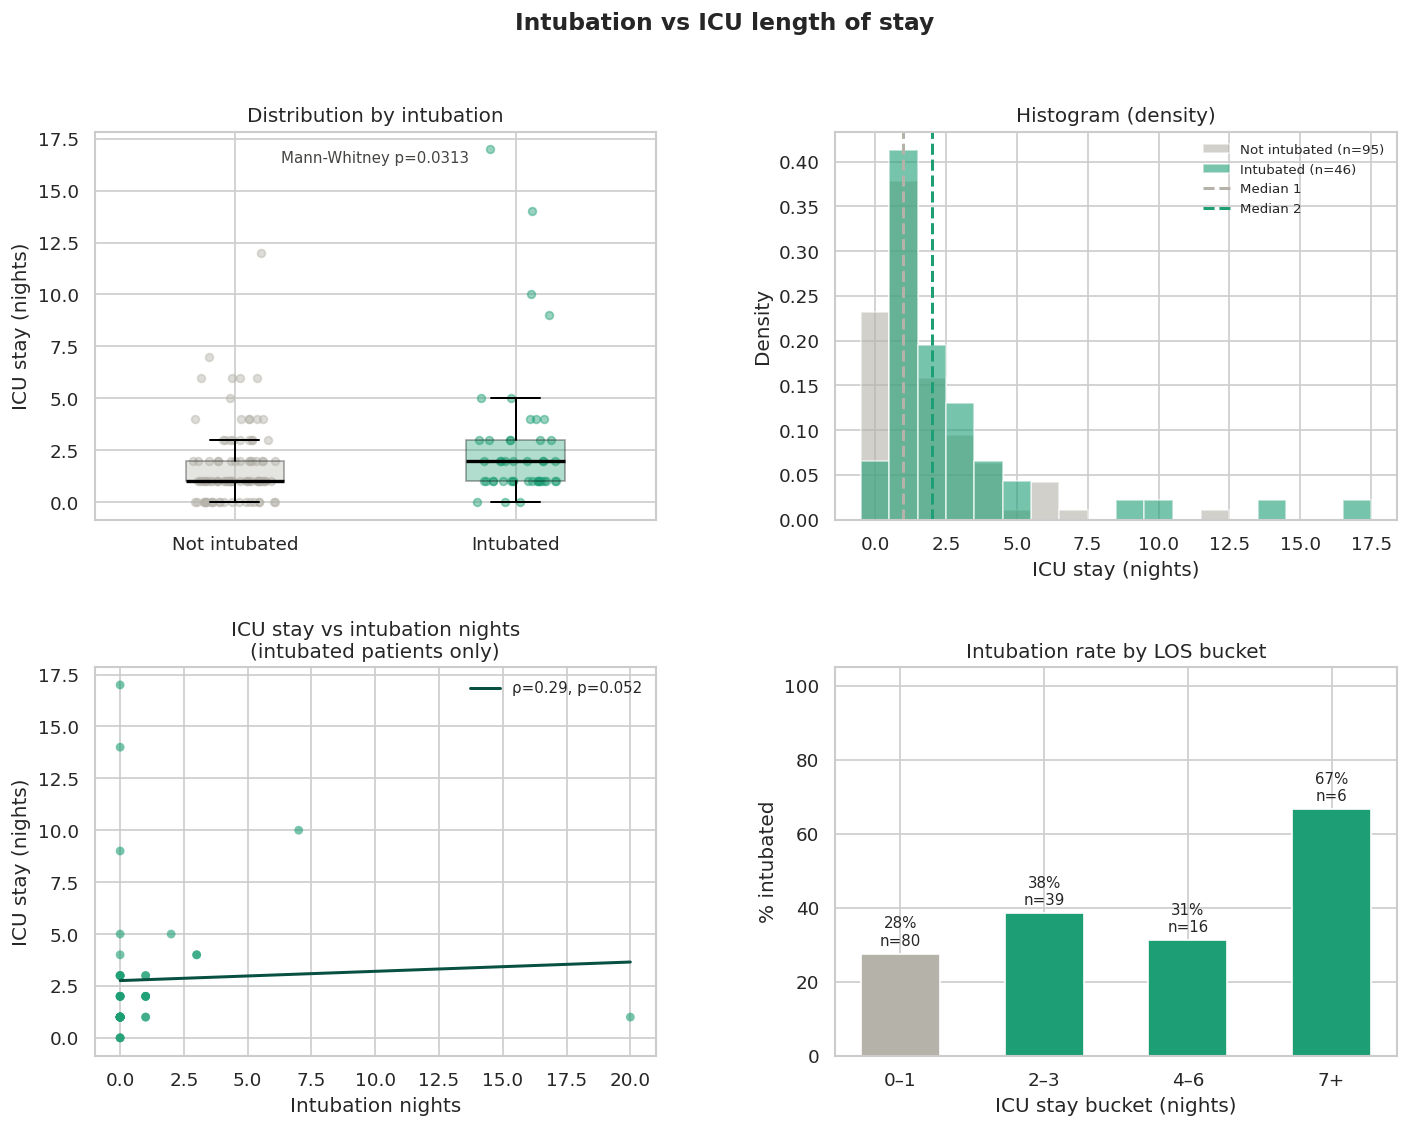


Saved: 01_intubation_vs_icu_stay.png


In [10]:
"""
Analysis 1 — Intubation vs ICU Stay
=====================================
Four plots, one statistical summary.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Prep ──────────────────────────────────────────────────────────────────────
df_plot = df[
    (df["age_years"] >= 0) & (df["age_years"] <= 110)
].copy()

df_plot["intubated"] = df_plot["intubation"] == "Yes"
df_plot["icu_los"]   = pd.to_numeric(df_plot["length_of_icu_stay_nights"], errors="coerce")
df_plot["intub_n"]   = pd.to_numeric(df_plot["intubation_nights"], errors="coerce")

yes = df_plot.loc[df_plot["intubated"],  "icu_los"].dropna()
no  = df_plot.loc[~df_plot["intubated"], "icu_los"].dropna()

# Stats
t, p_t       = stats.ttest_ind(yes, no, equal_var=False)
u, p_u       = stats.mannwhitneyu(yes, no, alternative="two-sided")
r_sp, p_sp   = stats.spearmanr(
    df_plot["intubated"].astype(int),
    df_plot["icu_los"].dropna().reindex(df_plot["intubated"].index)
)

print("=== Intubation vs ICU stay ===")
print(f"  Intubated   n={len(yes)}, median={yes.median():.1f}, mean={yes.mean():.1f}, IQR={yes.quantile(.25):.1f}–{yes.quantile(.75):.1f}")
print(f"  Not intub.  n={len(no)},  median={no.median():.1f}, mean={no.mean():.1f}, IQR={no.quantile(.25):.1f}–{no.quantile(.75):.1f}")
print(f"\n  Welch t-test:      t={t:.3f}, p={p_t:.4f}")
print(f"  Mann-Whitney U:    U={u:.0f}, p={p_u:.4f}")
print(f"  Spearman ρ:        ρ={r_sp:.3f}, p={p_sp:.4f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Intubation vs ICU length of stay", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

colors = {"Yes": "#1D9E75", "No": "#B4B2A9"}

# ── Plot 1: Boxplot with jitter ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

for i, (label, grp) in enumerate(zip(["No", "Yes"], [no, yes])):
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(grp))
    ax1.scatter(
        np.full(len(grp), i) + jitter, grp,
        color=colors[label], alpha=0.45, s=22, zorder=2
    )

bp = ax1.boxplot(
    [no, yes],
    positions=[0, 1],
    widths=0.35,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="", linestyle="none"),
    zorder=3,
)
for patch, label in zip(bp["boxes"], ["No", "Yes"]):
    patch.set_facecolor(colors[label])
    patch.set_alpha(0.35)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(["Not intubated", "Intubated"])
ax1.set_ylabel("ICU stay (nights)")
ax1.set_title("Distribution by intubation")
sig_label = f"Mann-Whitney p={p_u:.4f}"
ax1.text(0.5, 0.95, sig_label, transform=ax1.transAxes,
         ha="center", va="top", fontsize=9, color="#444441")


# ── Plot 2: Histogram overlay ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

bins = np.arange(0, max(yes.max(), no.max()) + 2, 1) - 0.5
ax2.hist(no,  bins=bins, color=colors["No"],  alpha=0.6, label=f"Not intubated (n={len(no)})",  density=True, edgecolor="white")
ax2.hist(yes, bins=bins, color=colors["Yes"], alpha=0.6, label=f"Intubated (n={len(yes)})", density=True, edgecolor="white")
ax2.axvline(no.median(),  color=colors["No"],  lw=1.8, linestyle="--", label=f"Median {no.median():.0f}")
ax2.axvline(yes.median(), color=colors["Yes"], lw=1.8, linestyle="--", label=f"Median {yes.median():.0f}")
ax2.set_xlabel("ICU stay (nights)")
ax2.set_ylabel("Density")
ax2.set_title("Histogram (density)")
ax2.legend(fontsize=8, frameon=False)


# ── Plot 3: ICU stay vs intubation nights (intubated only) ────────────────────
ax3 = fig.add_subplot(gs[1, 0])

intub_sub = df_plot[df_plot["intubated"]].dropna(subset=["icu_los", "intub_n"])
r2, p2 = stats.spearmanr(intub_sub["intub_n"], intub_sub["icu_los"])

ax3.scatter(intub_sub["intub_n"], intub_sub["icu_los"],
            color=colors["Yes"], alpha=0.6, s=28, edgecolors="none")

# Regression line
m, b, *_ = stats.linregress(intub_sub["intub_n"], intub_sub["icu_los"])
xs = np.linspace(intub_sub["intub_n"].min(), intub_sub["intub_n"].max(), 100)
ax3.plot(xs, m * xs + b, color="#085041", lw=1.8, label=f"ρ={r2:.2f}, p={p2:.3f}")
ax3.set_xlabel("Intubation nights")
ax3.set_ylabel("ICU stay (nights)")
ax3.set_title("ICU stay vs intubation nights\n(intubated patients only)")
ax3.legend(fontsize=9, frameon=False)


# ── Plot 4: Proportion intubated by ICU stay bucket ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

df_plot["los_bucket"] = pd.cut(
    df_plot["icu_los"],
    bins=[-0.5, 1.5, 3.5, 6.5, 100],
    labels=["0–1", "2–3", "4–6", "7+"]
)
prop = (
    df_plot.groupby("los_bucket", observed=True)["intubated"]
    .agg(["sum", "count"])
    .assign(pct=lambda x: x["sum"] / x["count"] * 100)
)
bars = ax4.bar(
    prop.index.astype(str), prop["pct"],
    color=[colors["Yes"] if v > 30 else colors["No"] for v in prop["pct"]],
    edgecolor="white", width=0.55
)
for bar, (_, row) in zip(bars, prop.iterrows()):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{row['pct']:.0f}%\nn={row['count']:.0f}",
        ha="center", va="bottom", fontsize=9
    )
ax4.set_xlabel("ICU stay bucket (nights)")
ax4.set_ylabel("% intubated")
ax4.set_title("Intubation rate by LOS bucket")
ax4.set_ylim(0, 105)


plt.savefig("plots/01_intubation_vs_icu_stay.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: 01_intubation_vs_icu_stay.png")

=== Admission reason vs ICU stay ===

Kruskal-Wallis: H=16.225, p=0.0062

Reason                            n  Median    Mean          IQR
----------------------------------------------------------------
Multi organ failure              13     3.0    3.15      2.0–4.0
Observation_other                29     2.0    2.00      1.0–3.0
Sepsis                           15     1.0    3.47      0.0–4.0
Observation_post_OP              54     1.0    1.67      1.0–2.0
Shock                            21     1.0    1.90      1.0–3.0
Head injury                       7     0.0    0.29      0.0–0.5

Pairwise Mann-Whitney (Bonferroni n=15):
Pair                                                      U    p_raw    p_adj   sig
----------------------------------------------------------------------------------
Multi organ failure vs Head injury                          84   0.0018   0.0277     *
Observation_post_OP vs Head injury                         327   0.0005   0.0079    **


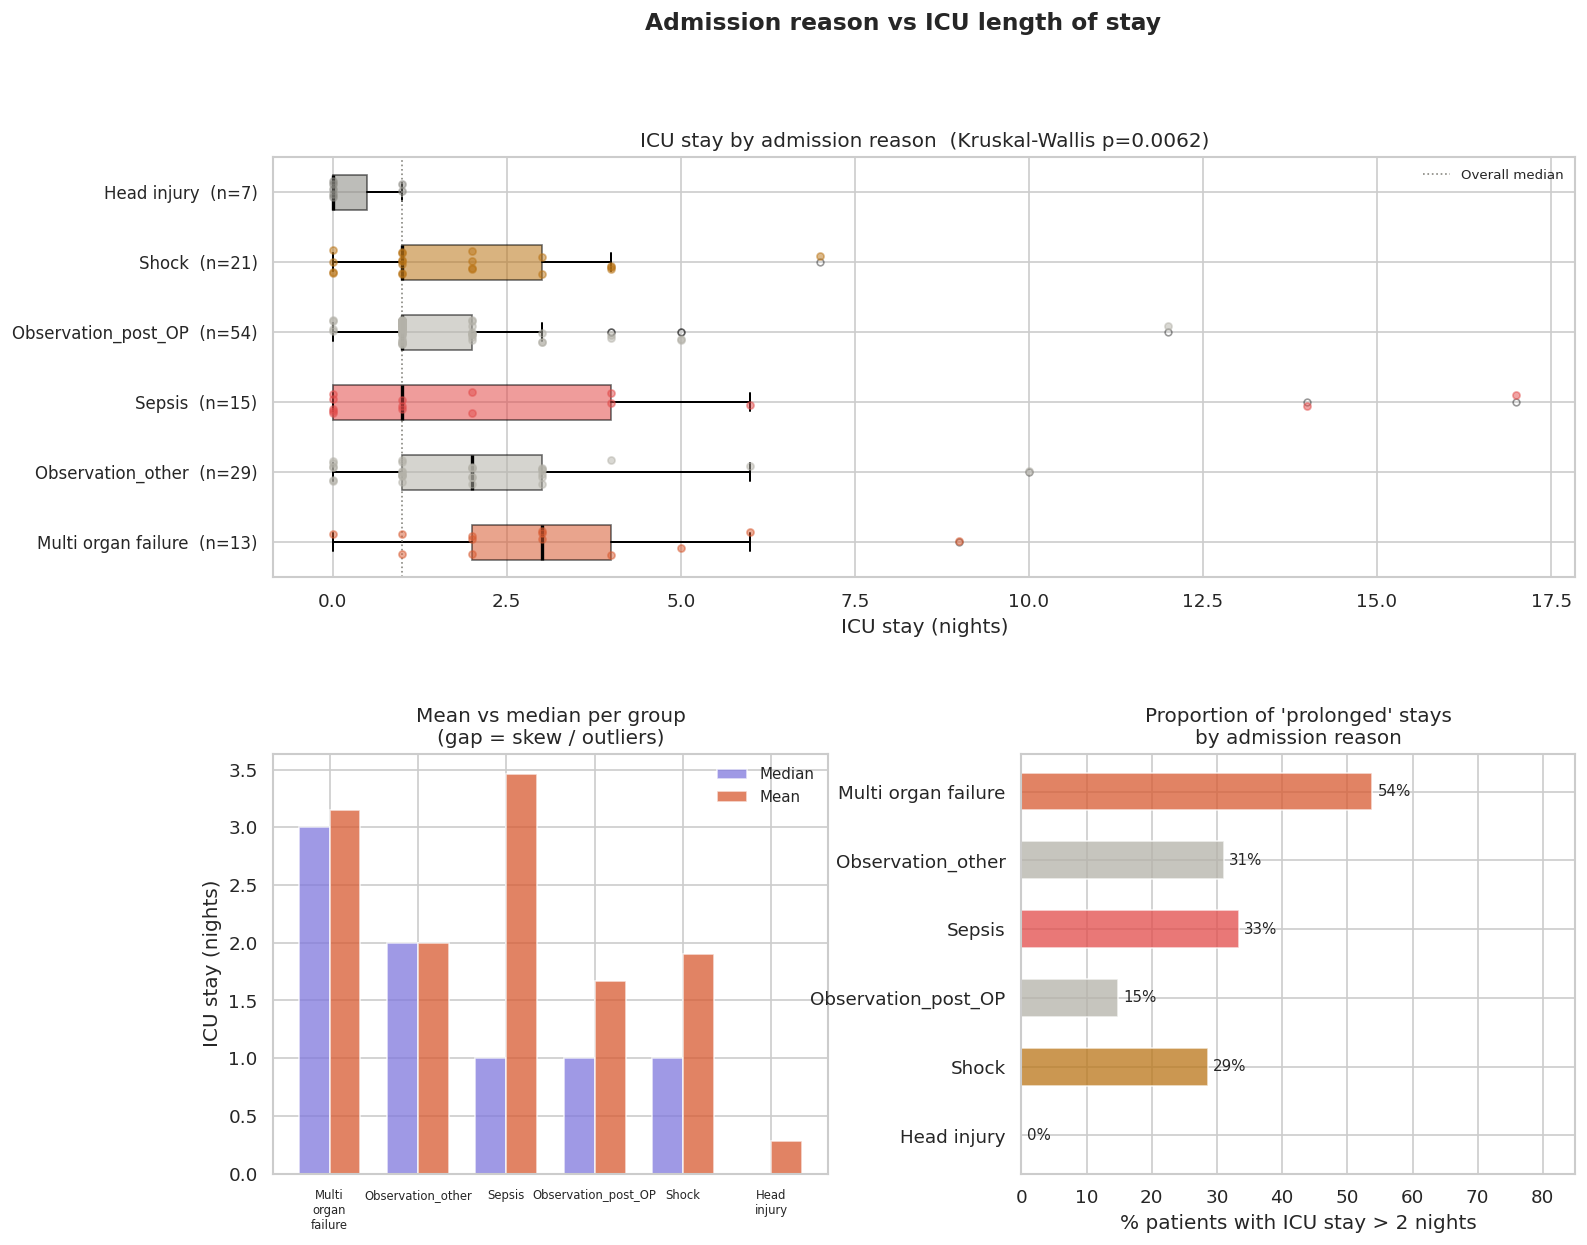


Saved: plots/02_admission_reason_vs_icu_stay.png


In [11]:
"""
Analysis 2 — Admission Reason vs ICU Stay
==========================================
Four plots + pairwise post-hoc tests.
Save to plots/02_admission_reason_vs_icu_stay.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from itertools import combinations

# ── Prep ──────────────────────────────────────────────────────────────────────
df_plot = df[
    (df["age_years"] >= 0) & (df["age_years"] <= 110)
].copy()

df_plot["icu_los"] = pd.to_numeric(df_plot["length_of_icu_stay_nights"], errors="coerce")

# Harmonise the two "Head injury" spellings
df_plot["reason"] = (
    df_plot["reason_for_admission_category"]
    .str.strip()
    .replace({"Head Injury": "Head injury", "Multi organ faliure": "Multi organ failure"})
)

# Keep only groups with n >= 5
counts = df_plot["reason"].value_counts()
valid_reasons = counts[counts >= 5].index
df_r = df_plot[df_plot["reason"].isin(valid_reasons)].dropna(subset=["icu_los", "reason"])

# Order groups by median LOS descending
order = (
    df_r.groupby("reason")["icu_los"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

groups = {r: df_r.loc[df_r["reason"] == r, "icu_los"].values for r in order}

# ── Stats ─────────────────────────────────────────────────────────────────────
H, p_kw = stats.kruskal(*groups.values())
print("=== Admission reason vs ICU stay ===")
print(f"\nKruskal-Wallis: H={H:.3f}, p={p_kw:.4f}\n")
print(f"{'Reason':<30} {'n':>4} {'Median':>7} {'Mean':>7} {'IQR':>12}")
print("-" * 64)
for r in order:
    g = groups[r]
    iqr = f"{np.percentile(g,25):.1f}–{np.percentile(g,75):.1f}"
    print(f"{r:<30} {len(g):>4} {np.median(g):>7.1f} {np.mean(g):>7.2f} {iqr:>12}")

# Pairwise Mann-Whitney with Bonferroni correction
pairs = list(combinations(order, 2))
n_tests = len(pairs)
print(f"\nPairwise Mann-Whitney (Bonferroni n={n_tests}):")
print(f"{'Pair':<50} {'U':>8} {'p_raw':>8} {'p_adj':>8} {'sig':>5}")
print("-" * 82)
for a, b in pairs:
    u, p_raw = stats.mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    p_adj = min(p_raw * n_tests, 1.0)
    sig = "***" if p_adj < .001 else "**" if p_adj < .01 else "*" if p_adj < .05 else "ns"
    if sig != "ns":
        print(f"{a} vs {b:<30} {u:>8.0f} {p_raw:>8.4f} {p_adj:>8.4f} {sig:>5}")

# ── Figure ────────────────────────────────────────────────────────────────────
palette = {
    "Multi organ failure":   "#D85A30",
    "Observation other":     "#7F77DD",
    "Shock":                 "#BA7517",
    "Sepsis":                "#E24B4A",
    "Observation post_OP":   "#1D9E75",
    "Head injury":           "#888780",
}
def get_color(r):
    return palette.get(r, "#B4B2A9")

fig = plt.figure(figsize=(14, 11))
fig.suptitle("Admission reason vs ICU length of stay", fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)


# ── Plot 1: Horizontal boxplot ordered by median ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # spans full top row

data_ordered = [groups[r] for r in order]
bp = ax1.boxplot(
    data_ordered,
    vert=False,
    positions=range(len(order)),
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=4, alpha=0.4, linestyle="none"),
)
for patch, r in zip(bp["boxes"], order):
    patch.set_facecolor(get_color(r))
    patch.set_alpha(0.55)

# Jitter
rng = np.random.default_rng(0)
for i, r in enumerate(order):
    g = groups[r]
    jitter = rng.uniform(-0.18, 0.18, len(g))
    ax1.scatter(g, np.full(len(g), i) + jitter,
                color=get_color(r), alpha=0.5, s=18, zorder=3)

ax1.set_yticks(range(len(order)))
ax1.set_yticklabels([f"{r}  (n={len(groups[r])})" for r in order], fontsize=10)
ax1.set_xlabel("ICU stay (nights)")
ax1.set_title(f"ICU stay by admission reason  (Kruskal-Wallis p={p_kw:.4f})")
ax1.axvline(df_r["icu_los"].median(), color="#888780", lw=1, linestyle=":", label="Overall median")
ax1.legend(fontsize=8, frameon=False)


# ── Plot 2: Mean vs median bar comparison ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

x = np.arange(len(order))
medians = [np.median(groups[r]) for r in order]
means   = [np.mean(groups[r])   for r in order]
w = 0.35
ax2.bar(x - w/2, medians, width=w, label="Median", color="#7F77DD", alpha=0.75, edgecolor="white")
ax2.bar(x + w/2, means,   width=w, label="Mean",   color="#D85A30", alpha=0.75, edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels([r.replace(" ", "\n") for r in order], fontsize=7)
ax2.set_ylabel("ICU stay (nights)")
ax2.set_title("Mean vs median per group\n(gap = skew / outliers)")
ax2.legend(fontsize=9, frameon=False)


# ── Plot 3: % patients staying > 2 nights ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

pct_long = {
    r: (groups[r] > 2).mean() * 100
    for r in order
}
bars = ax3.barh(
    list(pct_long.keys()),
    list(pct_long.values()),
    color=[get_color(r) for r in pct_long],
    alpha=0.75, edgecolor="white", height=0.55
)
for bar, (r, pct) in zip(bars, pct_long.items()):
    ax3.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
             f"{pct:.0f}%", va="center", fontsize=9)
ax3.set_xlabel("% patients with ICU stay > 2 nights")
ax3.set_title("Proportion of 'prolonged' stays\nby admission reason")
ax3.set_xlim(0, 85)
ax3.invert_yaxis()


plt.savefig("plots/02_admission_reason_vs_icu_stay.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: plots/02_admission_reason_vs_icu_stay.png")

=== Surgery type vs intubation rate ===

Chi-square: χ²=33.982, dof=8, p=0.0000

Surgery                                          n  Intub.    Rate
------------------------------------------------------------------
Other                                            7       5   71.4%
Exploratory Laparotomy                          26      18   69.2%
Hysterectomy                                     6       3   50.0%
Open Prostatectomy                               6       3   50.0%
Debridement                                      5       2   40.0%
Exploratory Laparotomy with Bowel Resection     14       5   35.7%
EGD                                              9       2   22.2%
Caesarean Section                                7       1   14.3%
No Surgery                                      40       3    7.5%

Fisher exact — each group vs rest (Bonferroni n=9):
Surgery                                           OR    p_raw    p_adj   sig
----------------------------------------------------

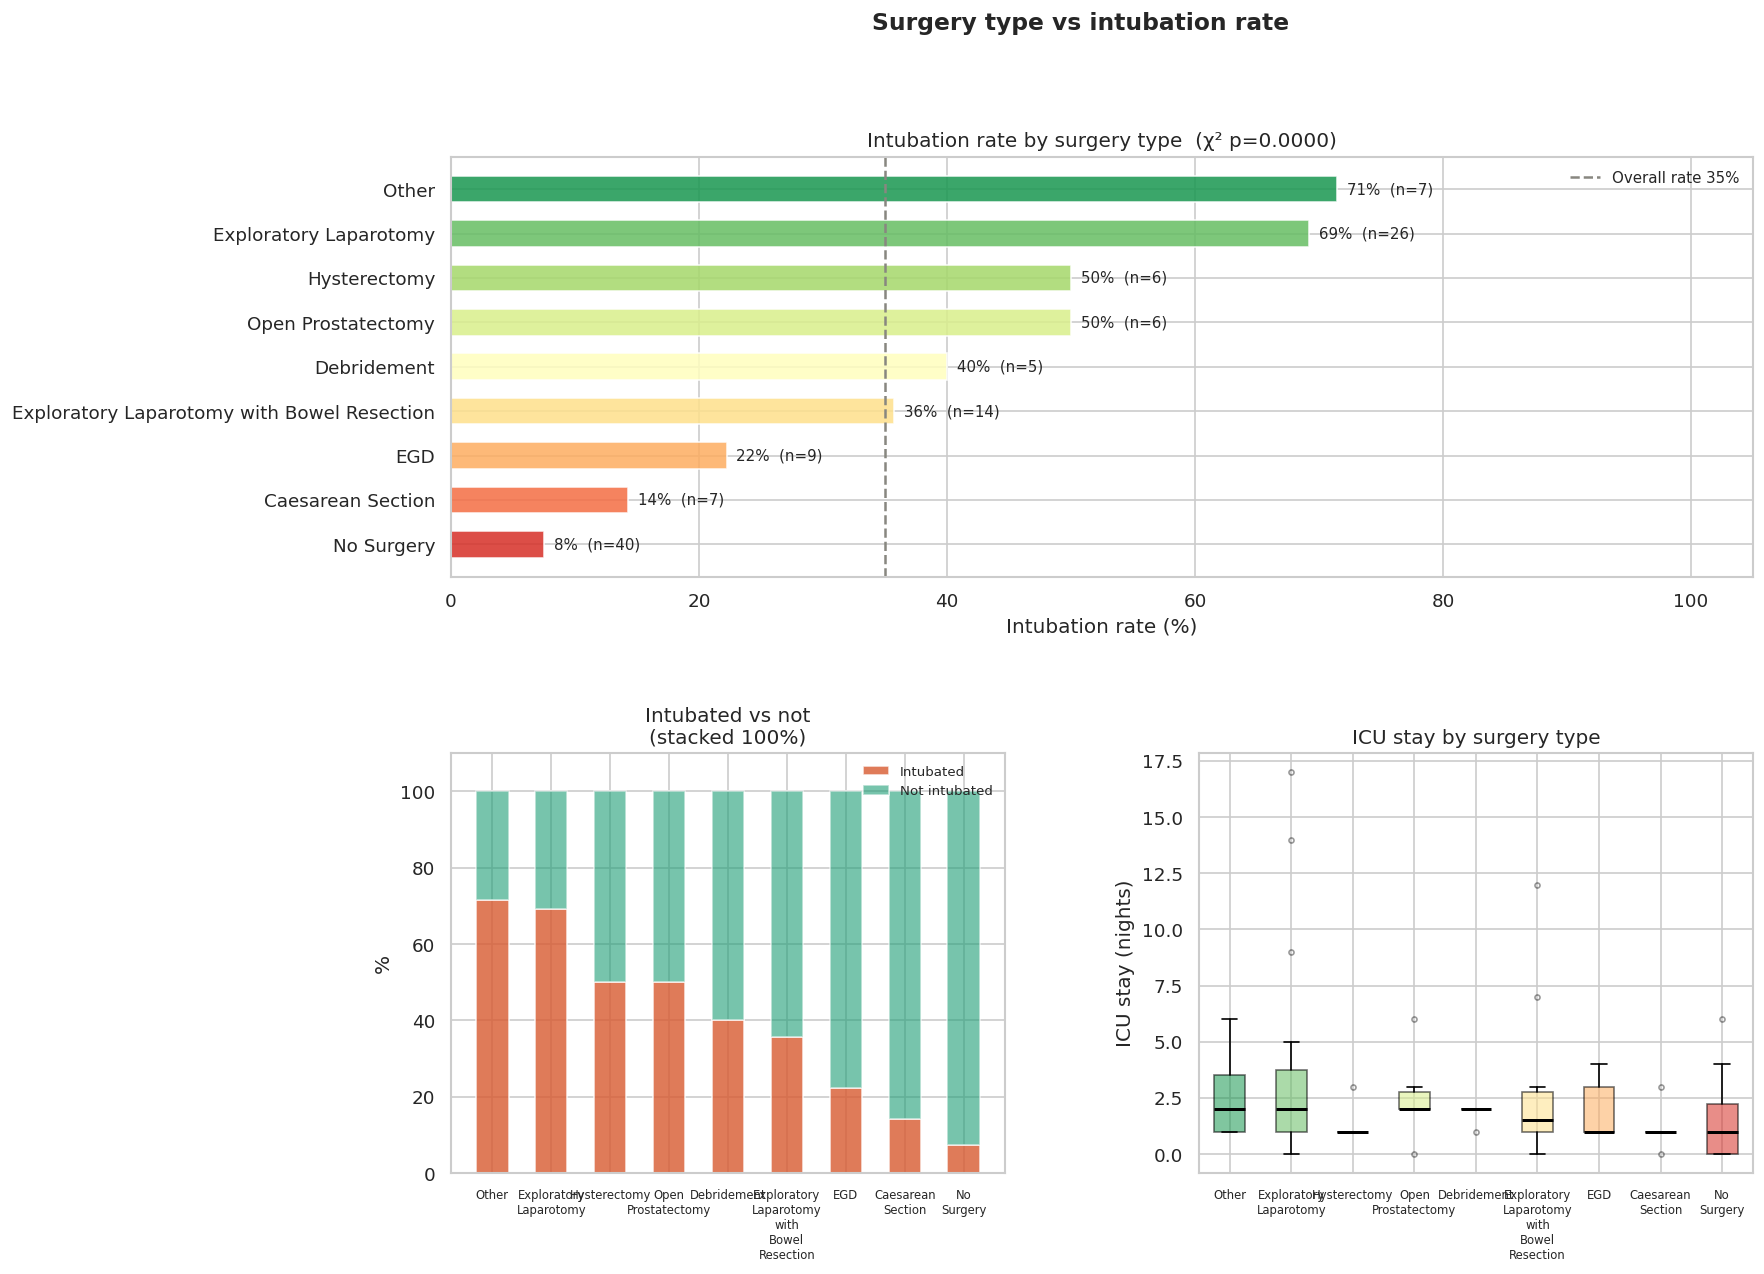


Saved: plots/03_surgery_type_vs_intubation.png


In [12]:
"""
Analysis 3 — Surgery Type vs Intubation Rate
=============================================
Four plots + chi-square / Fisher exact tests.
Save to plots/03_surgery_type_vs_intubation.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Prep ──────────────────────────────────────────────────────────────────────
df_plot = df[
    (df["age_years"] >= 0) & (df["age_years"] <= 110)
].copy()

df_plot["icu_los"]   = pd.to_numeric(df_plot["length_of_icu_stay_nights"], errors="coerce")
df_plot["intubated"] = (df_plot["intubation"] == "Yes").astype(int)
df_plot["surgery"]   = df_plot["type_of_surgery_grouped"].str.strip()

# Keep groups with n >= 4
counts = df_plot["surgery"].value_counts()
valid  = counts[counts >= 4].index
df_s   = df_plot[df_plot["surgery"].isin(valid)].dropna(subset=["surgery", "intubated"])

# Order by intubation rate descending
order = (
    df_s.groupby("surgery")["intubated"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# ── Stats ─────────────────────────────────────────────────────────────────────
ct = pd.crosstab(df_s["surgery"], df_s["intubated"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)

print("=== Surgery type vs intubation rate ===")
print(f"\nChi-square: χ²={chi2:.3f}, dof={dof}, p={p_chi:.4f}\n")
print(f"{'Surgery':<45} {'n':>4} {'Intub.':>7} {'Rate':>7}")
print("-" * 66)
for surg in order:
    sub  = df_s[df_s["surgery"] == surg]
    n    = len(sub)
    yes  = sub["intubated"].sum()
    rate = yes / n * 100
    print(f"{surg:<45} {n:>4} {yes:>7.0f} {rate:>6.1f}%")

# Fisher exact for each surgery vs all others (one-vs-rest)
print(f"\nFisher exact — each group vs rest (Bonferroni n={len(order)}):")
print(f"{'Surgery':<45} {'OR':>6} {'p_raw':>8} {'p_adj':>8} {'sig':>5}")
print("-" * 76)
for surg in order:
    a = df_s[df_s["surgery"] == surg]["intubated"].values
    b = df_s[df_s["surgery"] != surg]["intubated"].values
    ct2 = np.array([[( a==1).sum(), (a==0).sum()],
                    [( b==1).sum(), (b==0).sum()]])
    OR, p_raw = stats.fisher_exact(ct2)
    p_adj = min(p_raw * len(order), 1.0)
    sig = "***" if p_adj<.001 else "**" if p_adj<.01 else "*" if p_adj<.05 else "ns"
    print(f"{surg:<45} {OR:>6.2f} {p_raw:>8.4f} {p_adj:>8.4f} {sig:>5}")

# ── Palette ───────────────────────────────────────────────────────────────────
cmap_vals = plt.cm.RdYlGn_r(
    np.linspace(0.1, 0.9, len(order))
)
color_map = {s: cmap_vals[i] for i, s in enumerate(order)}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
fig.suptitle("Surgery type vs intubation rate", fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── Plot 1: Intubation rate bar chart (horizontal) ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])

rates = [df_s[df_s["surgery"] == s]["intubated"].mean() * 100 for s in order]
ns    = [counts[s] for s in order]

bars = ax1.barh(
    order, rates,
    color=[color_map[s] for s in order],
    edgecolor="white", height=0.6, alpha=0.85
)
for bar, rate, n in zip(bars, rates, ns):
    ax1.text(rate + 0.8, bar.get_y() + bar.get_height() / 2,
             f"{rate:.0f}%  (n={n})", va="center", fontsize=9)

ax1.axvline(df_s["intubated"].mean() * 100, color="#888780",
            lw=1.5, linestyle="--", label=f"Overall rate {df_s['intubated'].mean()*100:.0f}%")
ax1.set_xlabel("Intubation rate (%)")
ax1.set_title(f"Intubation rate by surgery type  (χ² p={p_chi:.4f})")
ax1.set_xlim(0, 105)
ax1.invert_yaxis()
ax1.legend(fontsize=9, frameon=False)


# ── Plot 2: Stacked 100% bar — intubated vs not ───────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

pct_yes = np.array([df_s[df_s["surgery"]==s]["intubated"].mean()*100 for s in order])
pct_no  = 100 - pct_yes
x = np.arange(len(order))
w = 0.55

ax2.bar(x, pct_yes, width=w, label="Intubated",     color="#D85A30", alpha=0.8, edgecolor="white")
ax2.bar(x, pct_no,  width=w, label="Not intubated", color="#1D9E75", alpha=0.6,
        edgecolor="white", bottom=pct_yes)
ax2.set_xticks(x)
ax2.set_xticklabels([s.replace(" ", "\n") for s in order], fontsize=7)
ax2.set_ylabel("%")
ax2.set_ylim(0, 110)
ax2.set_title("Intubated vs not\n(stacked 100%)")
ax2.legend(fontsize=8, frameon=False, loc="upper right")


# ── Plot 3: ICU stay by surgery type (boxplot) ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

df_s2 = df_s.dropna(subset=["icu_los"])
data_los = [df_s2.loc[df_s2["surgery"]==s, "icu_los"].values for s in order]

bp = ax3.boxplot(
    data_los,
    vert=True,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.8),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
    flierprops=dict(marker="o", markersize=3, alpha=0.4, linestyle="none"),
)
for patch, s in zip(bp["boxes"], order):
    patch.set_facecolor(color_map[s])
    patch.set_alpha(0.55)

ax3.set_xticks(range(1, len(order)+1))
ax3.set_xticklabels([s.replace(" ", "\n") for s in order], fontsize=7)
ax3.set_ylabel("ICU stay (nights)")
ax3.set_title("ICU stay by surgery type")


plt.savefig("plots/03_surgery_type_vs_intubation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: plots/03_surgery_type_vs_intubation.png")

=== Sepsis ICU stay breakdown ===
     age_years  icu_los  intubated   died type_of_surgery_grouped      diagnosis_that_lead_to_admission                    cause_of_death     disability_at_discharge
2           46      1.0      False   True                     EGD                  Advanced HIV Disease  Possible Cryptococcal Meningitis                       Death
6           17     14.0       True  False  Exploratory Laparotomy                         Typhoid Fever                               NaN  Potential Of Full Recovery
11          17      6.0      False  False                   Other                Recurrent Septic Shock                               NaN  Potential Of Full Recovery
19          52      2.0       True  False             Debridement                          Septic Shock                               NaN                  Palliative
24          34      1.0       True   True  Exploratory Laparotomy                   Primary Peritonitis                   Pulmonary Edem

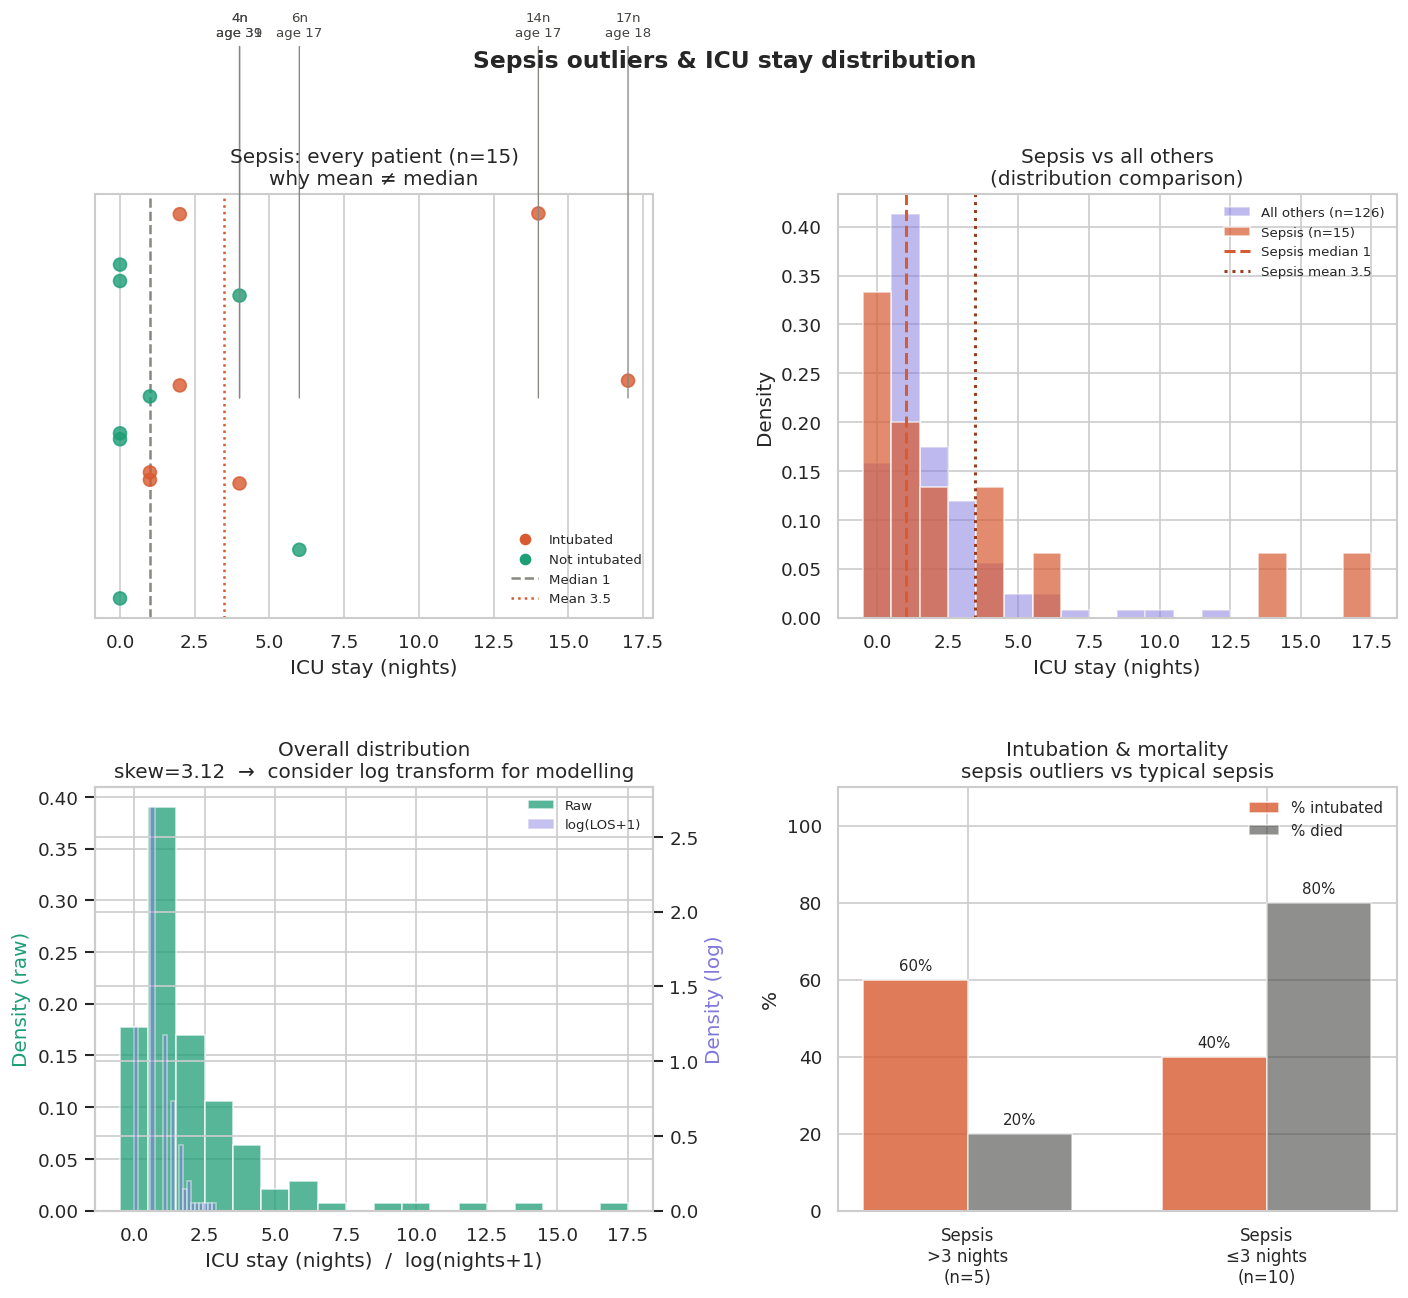


Saved: plots/04_sepsis_and_stay_distribution.png


In [13]:
"""
Analysis 4 — Sepsis Outliers & Stay Distribution
=================================================
Investigates why sepsis median=1 but mean=3.47,
and explores the overall ICU stay distribution shape.
Save to plots/04_sepsis_and_stay_distribution.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Prep ──────────────────────────────────────────────────────────────────────
df_plot = df[
    (df["age_years"] >= 0) & (df["age_years"] <= 110)
].copy()

df_plot["icu_los"]   = pd.to_numeric(df_plot["length_of_icu_stay_nights"], errors="coerce")
df_plot["intubated"] = (df_plot["intubation"] == "Yes")
df_plot["reason"]    = (
    df_plot["reason_for_admission_category"]
    .str.strip()
    .replace({"Head Injury": "Head injury", "Multi organ faliure": "Multi organ failure"})
)
df_plot["died"] = (df_plot["discharge_to"] == "Death")

sepsis = df_plot[df_plot["reason"] == "Sepsis"].dropna(subset=["icu_los"])
others = df_plot[df_plot["reason"] != "Sepsis"].dropna(subset=["icu_los"])

# ── Stats ─────────────────────────────────────────────────────────────────────
print("=== Sepsis ICU stay breakdown ===")
print(sepsis[["age_years","icu_los","intubated","died",
              "type_of_surgery_grouped","diagnosis_that_lead_to_admission",
              "cause_of_death","disability_at_discharge"]].to_string())

print(f"\n  n={len(sepsis)}")
print(f"  Median : {sepsis['icu_los'].median():.1f}")
print(f"  Mean   : {sepsis['icu_los'].mean():.2f}")
print(f"  IQR    : {sepsis['icu_los'].quantile(.25):.1f} – {sepsis['icu_los'].quantile(.75):.1f}")
print(f"  Max    : {sepsis['icu_los'].max():.0f}")
print(f"  % intubated : {sepsis['intubated'].mean()*100:.0f}%")
print(f"  % died      : {sepsis['died'].mean()*100:.0f}%")
print(f"\n  Outliers (>3 nights):")
print(sepsis[sepsis["icu_los"] > 3][["age_years","icu_los","intubated","died","cause_of_death"]].to_string())

# Overall distribution stats
los_all = df_plot["icu_los"].dropna()
print(f"\n=== Overall ICU stay distribution ===")
print(f"  n={len(los_all)}, mean={los_all.mean():.2f}, median={los_all.median():.1f}")
print(f"  Skewness={los_all.skew():.2f}, Kurtosis={los_all.kurt():.2f}")
print(f"  % staying 0–1 nights : {(los_all <= 1).mean()*100:.1f}%")
print(f"  % staying 2–3 nights : {((los_all > 1) & (los_all <= 3)).mean()*100:.1f}%")
print(f"  % staying > 3 nights : {(los_all > 3).mean()*100:.1f}%")

# Shapiro-Wilk normality test
stat_sw, p_sw = stats.shapiro(los_all)
print(f"\n  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.6f}")
stat_sw_log, p_sw_log = stats.shapiro(np.log1p(los_all))
print(f"  Shapiro-Wilk (log+1 transformed): W={stat_sw_log:.4f}, p={p_sw_log:.6f}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
fig.suptitle("Sepsis outliers & ICU stay distribution", fontsize=14, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.33)


# ── Plot 1: Sepsis individual patient strip ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

colors_s = sepsis["intubated"].map({True: "#D85A30", False: "#1D9E75"})
rng = np.random.default_rng(1)
jitter = rng.uniform(-0.2, 0.2, len(sepsis))

ax1.scatter(sepsis["icu_los"], jitter,
            c=colors_s, s=60, alpha=0.8, zorder=3)

# Annotate outliers
for _, row in sepsis[sepsis["icu_los"] > 3].iterrows():
    ax1.annotate(
        f"{row['icu_los']:.0f}n\nage {row['age_years']}",
        xy=(row["icu_los"], 0),
        xytext=(row["icu_los"], 0.35),
        fontsize=8, ha="center",
        arrowprops=dict(arrowstyle="-", color="#888780", lw=0.8),
        color="#444441"
    )

ax1.axvline(sepsis["icu_los"].median(), color="#888780", lw=1.5,
            linestyle="--", label=f"Median {sepsis['icu_los'].median():.0f}")
ax1.axvline(sepsis["icu_los"].mean(), color="#D85A30", lw=1.5,
            linestyle=":", label=f"Mean {sepsis['icu_los'].mean():.1f}")

# Custom legend for colour
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#D85A30", markersize=8, label="Intubated"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#1D9E75", markersize=8, label="Not intubated"),
    Line2D([0],[0], color="#888780", lw=1.5, linestyle="--", label=f"Median {sepsis['icu_los'].median():.0f}"),
    Line2D([0],[0], color="#D85A30", lw=1.5, linestyle=":", label=f"Mean {sepsis['icu_los'].mean():.1f}"),
]
ax1.legend(handles=handles, fontsize=8, frameon=False)
ax1.set_xlabel("ICU stay (nights)")
ax1.set_yticks([])
ax1.set_title(f"Sepsis: every patient (n={len(sepsis)})\nwhy mean ≠ median")


# ── Plot 2: Sepsis vs all other reasons — overlaid density ───────────────────
ax2 = fig.add_subplot(gs[0, 1])

bins = np.arange(-0.5, 18.5, 1)
ax2.hist(others["icu_los"], bins=bins, density=True,
         color="#7F77DD", alpha=0.5, edgecolor="white", label=f"All others (n={len(others)})")
ax2.hist(sepsis["icu_los"], bins=bins, density=True,
         color="#D85A30", alpha=0.7, edgecolor="white", label=f"Sepsis (n={len(sepsis)})")
ax2.axvline(sepsis["icu_los"].median(), color="#D85A30", lw=1.8,
            linestyle="--", label=f"Sepsis median {sepsis['icu_los'].median():.0f}")
ax2.axvline(sepsis["icu_los"].mean(), color="#993C1D", lw=1.8,
            linestyle=":", label=f"Sepsis mean {sepsis['icu_los'].mean():.1f}")
ax2.set_xlabel("ICU stay (nights)")
ax2.set_ylabel("Density")
ax2.set_title("Sepsis vs all others\n(distribution comparison)")
ax2.legend(fontsize=8, frameon=False)


# ── Plot 3: Overall ICU stay distribution + log transform comparison ──────────
ax3 = fig.add_subplot(gs[1, 0])

ax3.hist(los_all, bins=np.arange(-0.5, 18.5, 1),
         color="#1D9E75", alpha=0.75, edgecolor="white", density=True, label="Raw")
ax3_twin = ax3.twinx()
ax3_twin.hist(np.log1p(los_all), bins=20,
              color="#7F77DD", alpha=0.45, edgecolor="white",
              density=True, label="log(LOS+1)")
ax3.set_xlabel("ICU stay (nights)  /  log(nights+1)")
ax3.set_ylabel("Density (raw)", color="#1D9E75")
ax3_twin.set_ylabel("Density (log)", color="#7F77DD")
ax3.set_title(f"Overall distribution\nskew={los_all.skew():.2f}  →  consider log transform for modelling")

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, frameon=False)


# ── Plot 4: Mortality & intubation rate for sepsis outliers vs typical ────────
ax4 = fig.add_subplot(gs[1, 1])

sepsis["group"] = np.where(sepsis["icu_los"] > 3, "Sepsis\n>3 nights", "Sepsis\n≤3 nights")
summary = sepsis.groupby("group").agg(
    n=("icu_los", "count"),
    pct_intubated=("intubated", "mean"),
    pct_died=("died", "mean"),
).reset_index()
summary["pct_intubated"] *= 100
summary["pct_died"]      *= 100

x  = np.arange(len(summary))
w  = 0.35
b1 = ax4.bar(x - w/2, summary["pct_intubated"], width=w,
             color="#D85A30", alpha=0.8, edgecolor="white", label="% intubated")
b2 = ax4.bar(x + w/2, summary["pct_died"],      width=w,
             color="#444441", alpha=0.6, edgecolor="white", label="% died")

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 1.5,
             f"{h:.0f}%", ha="center", va="bottom", fontsize=9)

ax4.set_xticks(x)
ax4.set_xticklabels(
    [f"{row['group']}\n(n={row['n']})" for _, row in summary.iterrows()],
    fontsize=10
)
ax4.set_ylabel("%")
ax4.set_ylim(0, 110)
ax4.set_title("Intubation & mortality\nsepsis outliers vs typical sepsis")
ax4.legend(fontsize=9, frameon=False)


plt.savefig("plots/04_sepsis_and_stay_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: plots/04_sepsis_and_stay_distribution.png")